# Imports

In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_groq import ChatGroq
from dotenv import load_dotenv

# Loading env variables

In [2]:
load_dotenv()

True

# Define LLM

In [5]:
model = ChatGroq(
    model="qwen/qwen3-32b"    # other params...
)

# Define State

In [6]:
class BlogState(TypedDict):
     
     title : str
     outline : str
     content : str

# Creating Nodes

In [8]:
def create_oultine(state: BlogState) -> BlogState:

    # fetch title
    title = state['title']

    # call llm gen outline
    prompt = f'Generate a detailed outline for a blog on the topic - {title}'
    outline = model.invoke(prompt).content

    # update state
    state['outline'] = outline

    return state

In [9]:
def create_blog(state: BlogState) -> BlogState:

    title = state['title']
    outline = state['outline']

    Prompt = f'write a detailed blog on the title - {title} using the following outline \n {outline}'

    content = model.invoke(Prompt).content

    state['content'] = content

    return state

# Define and Compile Graph

In [10]:
graph = StateGraph(BlogState)

#nodes
graph.add_node('create_oultine',create_oultine)
graph.add_node('create_blog',create_blog)

#edges
graph.add_edge(START,'create_oultine')
graph.add_edge('create_oultine','create_blog')
graph.add_edge('create_blog',END)

workflow = graph.compile()


In [11]:
intial_state = {'title' : 'Rise of AI in India'}

final_state = workflow.invoke(intial_state)

print(final_state)

{'title': 'Rise of AI in India', 'outline': '<think>\nOkay, I need to create a detailed outline for a blog on the "Rise of AI in India." Let me start by breaking down the main sections. First, an introduction to set the context. Then, maybe a section on the current state of AI in India. I should cover key sectors where AI is making an impact, like healthcare, education, agriculture, etc. Also, government initiatives are important, like NITI Aayog\'s policies. Challenges would be another section—data privacy, talent gap, infrastructure issues. Future outlook and case studies could follow. Finally, a conclusion.\n\nWait, the user wants a detailed outline, so each of these sections should have subsections. Let me think about the introduction. It should explain why AI is important now and mention India\'s unique position. Then, the current state could include stats on investment, startups, research institutions. For sectors, maybe pick 4-5 and elaborate on each. Government initiatives need

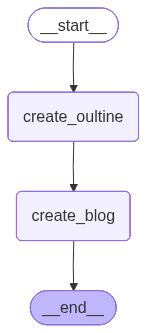

In [12]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())